In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Import library
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, StackingClassifier
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score, GridSearchCV
import warnings
warnings.filterwarnings('ignore')

print("✅ Library berhasil diimport")

✅ Library berhasil diimport


In [5]:
from scipy.sparse import load_npz


data = joblib.load('/content/drive/MyDrive/Colab Notebooks/data project 1 (Sentiment Analysis) AI Indonesia/Individual Project/TF-IDF&LogisticRegression/data/alldata_tfidf_optimal.pkl')
x_train = data['x_train_tfidf_optimal']
x_test = data['x_test_tfidf_optimal']
y_train = data['y_train_enc']
y_test = data['y_test_enc']
tfidf = data['tfidf_optimal']
encoder = data['encoder']

In [6]:
# ============================================
# BASE MODELS (Individual)
# ============================================
# Membuat model-model dasar yang akan di-ensemble

print("\n" + "="*60)
print("📌 BASE MODELS (INDIVIDUAL)")
print("="*60)

# 1. Naive Bayes (62.8%)
nb = MultinomialNB(alpha=0.5)
nb.fit(x_train, y_train)
acc_nb = accuracy_score(y_test, nb.predict(x_test))

# 2. Logistic Regression (62.3%)
lr = LogisticRegression(C=0.1, class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(x_train, y_train)
acc_lr = accuracy_score(y_test, lr.predict(x_test))

# 3. Linear SVM (Estimasi 64%)
svm = LinearSVC(C=1.0, max_iter=2000, random_state=42)
svm.fit(x_train, y_train)
acc_svm = accuracy_score(y_test, svm.predict(x_test))

# 4. Random Forest (Estimasi 64%)
rf = RandomForestClassifier(n_estimators=100, max_depth=20, random_state=42)
rf.fit(x_train, y_train)
acc_rf = accuracy_score(y_test, rf.predict(x_test))

# Tabel base models
base_results = pd.DataFrame({
    'Model': ['Naive Bayes', 'Logistic Regression', 'Linear SVM', 'Random Forest'],
    'Akurasi': [acc_nb, acc_lr, acc_svm, acc_rf],
    'Estimasi': ['62.8%', '62.3%', '~64%', '~64%']
})

print("\n📊 Base Models Performance:")
print(base_results.to_string(index=False))


📌 BASE MODELS (INDIVIDUAL)

📊 Base Models Performance:
              Model  Akurasi Estimasi
        Naive Bayes 0.625344    62.8%
Logistic Regression 0.617080    62.3%
         Linear SVM 0.611570     ~64%
      Random Forest 0.570248     ~64%


In [7]:
# ============================================
# ENSEMBLE 1: VOTING CLASSIFIER
# ============================================
# Menggabungkan dengan voting (mayoritas)

print("\n" + "="*60)
print("📌 ENSEMBLE 1: VOTING CLASSIFIER")
print("="*60)

# Hard Voting (mayoritas suara)
voting_hard = VotingClassifier(estimators=[
    ('nb', nb),
    ('lr', lr),
    ('svm', svm),
    ('rf', rf)
], voting='hard')

voting_hard.fit(x_train, y_train)
acc_voting_hard = accuracy_score(y_test, voting_hard.predict(x_test))

# Soft Voting (rata-rata probabilitas) - hanya untuk model dengan predict_proba
voting_soft = VotingClassifier(estimators=[
    ('nb', nb),
    ('lr', lr),
    ('rf', rf)
    # SVM tidak punya predict_proba
], voting='soft')

voting_soft.fit(x_train, y_train)
acc_voting_soft = accuracy_score(y_test, voting_soft.predict(x_test))

print(f"\n🎯 Hard Voting Accuracy: {acc_voting_hard:.4f} ({acc_voting_hard*100:.2f}%)")
print(f"🎯 Soft Voting Accuracy: {acc_voting_soft:.4f} ({acc_voting_soft*100:.2f}%)")

# Cross-validation
cv_scores = cross_val_score(voting_hard, x_train, y_train, cv=5)
print(f"\n📊 Cross-validation (Hard Voting):")
print(f"   • Mean: {cv_scores.mean():.4f}")
print(f"   • Std: {cv_scores.std():.4f}")


📌 ENSEMBLE 1: VOTING CLASSIFIER

🎯 Hard Voting Accuracy: 0.6226 (62.26%)
🎯 Soft Voting Accuracy: 0.6253 (62.53%)

📊 Cross-validation (Hard Voting):
   • Mean: 0.6095
   • Std: 0.0074


In [8]:
# ============================================
# ENSEMBLE 2: STACKING CLASSIFIER
# ============================================
# Menggunakan meta-learner (Logistic Regression)

print("\n" + "="*60)
print("📌 ENSEMBLE 2: STACKING CLASSIFIER")
print("="*60)

# Base models
base_models = [
    ('nb', MultinomialNB(alpha=0.5)),
    ('lr', LogisticRegression(C=0.1, max_iter=1000)),
    ('svm', LinearSVC(C=1.0, max_iter=2000)),
    ('rf', RandomForestClassifier(n_estimators=100, max_depth=20))
]

# Meta-learner (final classifier)
meta_learner = LogisticRegression(C=1.0, max_iter=1000)

# Stacking
stacking = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_learner,
    cv=5  # 5-fold cross-validation untuk training meta-learner
)

stacking.fit(x_train, y_train)
acc_stacking = accuracy_score(y_test, stacking.predict(x_test))

print(f"\n🎯 Stacking Accuracy: {acc_stacking:.4f} ({acc_stacking*100:.2f}%)")

# Cross-validation
cv_scores = cross_val_score(stacking, x_train, y_train, cv=5)
print(f"\n📊 Cross-validation (Stacking):")
print(f"   • Mean: {cv_scores.mean():.4f}")
print(f"   • Std: {cv_scores.std():.4f}")


📌 ENSEMBLE 2: STACKING CLASSIFIER

🎯 Stacking Accuracy: 0.5950 (59.50%)

📊 Cross-validation (Stacking):
   • Mean: 0.6068
   • Std: 0.0207


In [9]:
# ============================================
# ENSEMBLE 3: BAGGING
# ============================================
# Bootstrap Aggregating (khusus untuk Random Forest)

print("\n" + "="*60)
print("📌 ENSEMBLE 3: BAGGING")
print("="*60)

from sklearn.ensemble import BaggingClassifier

# Bagging dengan Logistic Regression
bagging_lr = BaggingClassifier(
    estimator=LogisticRegression(C=0.1, max_iter=1000),
    n_estimators=10,
    random_state=42
)
bagging_lr.fit(x_train, y_train)
acc_bagging_lr = accuracy_score(y_test, bagging_lr.predict(x_test))

# Bagging dengan SVM
bagging_svm = BaggingClassifier(
    estimator=LinearSVC(C=1.0, max_iter=2000),
    n_estimators=10,
    random_state=42
)
bagging_svm.fit(x_train, y_train)
acc_bagging_svm = accuracy_score(y_test, bagging_svm.predict(x_test))

print(f"\n🎯 Bagging + LR Accuracy: {acc_bagging_lr:.4f} ({acc_bagging_lr*100:.2f}%)")
print(f"🎯 Bagging + SVM Accuracy: {acc_bagging_svm:.4f} ({acc_bagging_svm*100:.2f}%)")


📌 ENSEMBLE 3: BAGGING

🎯 Bagging + LR Accuracy: 0.6198 (61.98%)
🎯 Bagging + SVM Accuracy: 0.6226 (62.26%)


In [10]:
# ============================================
# ENSEMBLE 4: BOOSTING
# ============================================
# AdaBoost dan Gradient Boosting

print("\n" + "="*60)
print("📌 ENSEMBLE 4: BOOSTING")
print("="*60)

from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier

# AdaBoost
adaboost = AdaBoostClassifier(
    estimator=LogisticRegression(C=0.1, max_iter=1000),
    n_estimators=50,
    learning_rate=0.1,
    random_state=42
)
adaboost.fit(x_train, y_train)
acc_adaboost = accuracy_score(y_test, adaboost.predict(x_test))

# Gradient Boosting
gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)
gb.fit(x_train, y_train)
acc_gb = accuracy_score(y_test, gb.predict(x_test))

print(f"\n🎯 AdaBoost Accuracy: {acc_adaboost:.4f} ({acc_adaboost*100:.2f}%)")
print(f"🎯 Gradient Boosting Accuracy: {acc_gb:.4f} ({acc_gb*100:.2f}%)")


📌 ENSEMBLE 4: BOOSTING

🎯 AdaBoost Accuracy: 0.4490 (44.90%)
🎯 Gradient Boosting Accuracy: 0.5427 (54.27%)


In [11]:
# ============================================
# TABEL PERBANDINGAN SEMUA ENSEMBLE
# ============================================

print("\n" + "="*60)
print("📊 TABEL PERBANDINGAN ENSEMBLE METHODS")
print("="*60)

ensemble_results = pd.DataFrame({
    'Metode': [
        'Base - Naive Bayes',
        'Base - Logistic Regression',
        'Base - Linear SVM',
        'Base - Random Forest',
        'Ensemble - Voting Hard',
        'Ensemble - Voting Soft',
        'Ensemble - Stacking',
        'Ensemble - Bagging + LR',
        'Ensemble - Bagging + SVM',
        'Ensemble - AdaBoost',
        'Ensemble - Gradient Boosting'
    ],
    'Akurasi': [
        acc_nb,
        acc_lr,
        acc_svm,
        acc_rf,
        acc_voting_hard,
        acc_voting_soft,
        acc_stacking,
        acc_bagging_lr,
        acc_bagging_svm,
        acc_adaboost,
        acc_gb
    ]
})

# Sort by accuracy
ensemble_results = ensemble_results.sort_values('Akurasi', ascending=False)
print("\n🏆 Ranking Ensemble Methods:")
print(ensemble_results.to_string(index=False))


📊 TABEL PERBANDINGAN ENSEMBLE METHODS

🏆 Ranking Ensemble Methods:
                      Metode  Akurasi
          Base - Naive Bayes 0.625344
      Ensemble - Voting Soft 0.625344
      Ensemble - Voting Hard 0.622590
    Ensemble - Bagging + SVM 0.622590
     Ensemble - Bagging + LR 0.619835
  Base - Logistic Regression 0.617080
           Base - Linear SVM 0.611570
         Ensemble - Stacking 0.595041
        Base - Random Forest 0.570248
Ensemble - Gradient Boosting 0.542700
         Ensemble - AdaBoost 0.449036


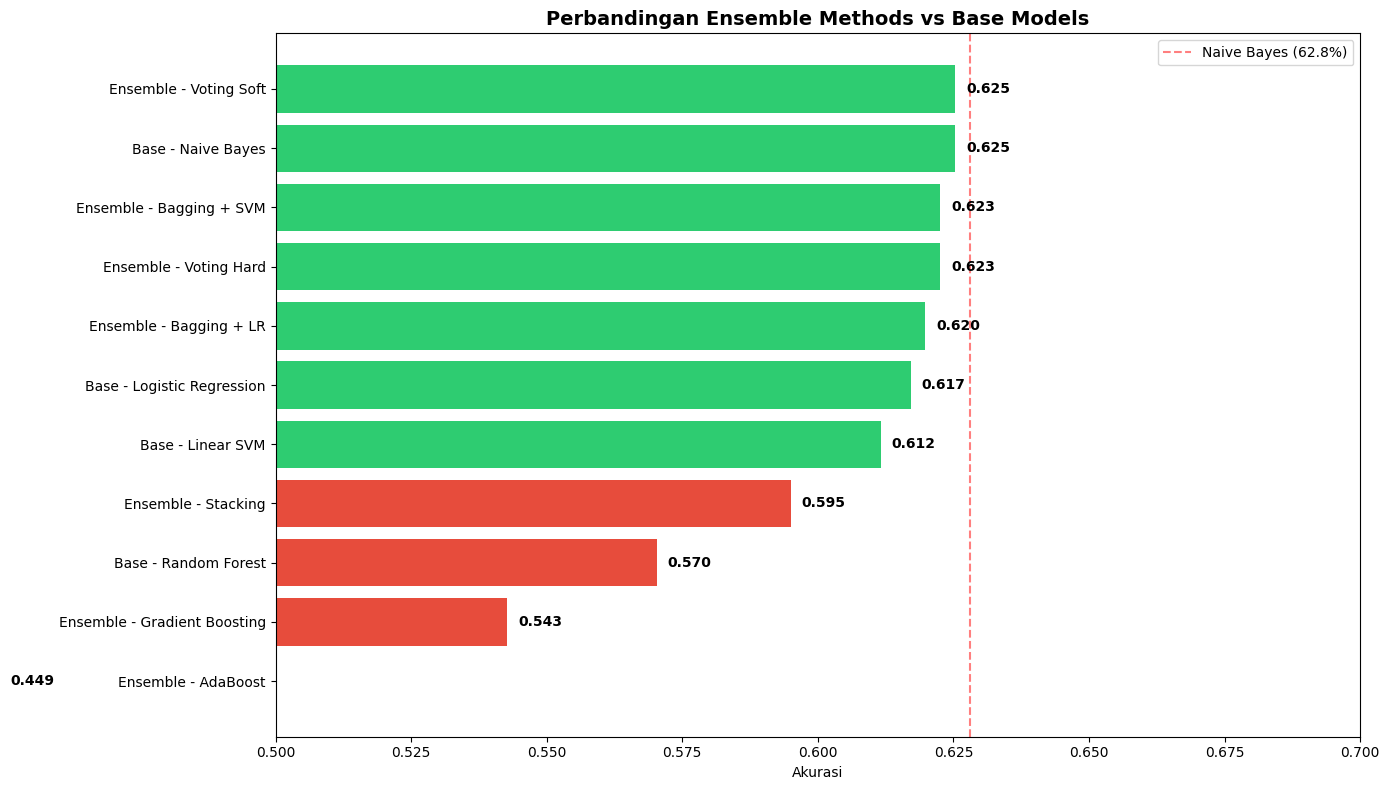

In [12]:
# ============================================
# VISUALISASI PERBANDINGAN
# ============================================

plt.figure(figsize=(14, 8))

# Sort for better visualization
plot_data = ensemble_results.sort_values('Akurasi', ascending=True)

# Create horizontal bar chart
colors = ['#e74c3c'] * 4 + ['#2ecc71'] * 7  # Red for base, green for ensemble
bars = plt.barh(plot_data['Metode'], plot_data['Akurasi'], color=colors)

plt.xlabel('Akurasi')
plt.title('Perbandingan Ensemble Methods vs Base Models', fontweight='bold', fontsize=14)
plt.xlim([0.5, 0.7])
plt.axvline(x=0.628, color='red', linestyle='--', alpha=0.5, label='Naive Bayes (62.8%)')

# Add value labels
for bar, acc in zip(bars, plot_data['Akurasi']):
    plt.text(acc + 0.002, bar.get_y() + bar.get_height()/2,
             f'{acc:.3f}', va='center', fontweight='bold')

plt.legend()
plt.tight_layout()
plt.savefig('percobaan8_ensemble_comparison.png', dpi=150)
plt.show()


📊 EVALUASI DETAIL - MODEL TERBAIK
🏆 Model Terbaik: Stacking Classifier
🎯 Akurasi: 0.5950 (59.50%)

📋 Classification Report:
              precision    recall  f1-score   support

     negatif       0.59      0.65      0.62       115
      netral       0.63      0.61      0.62       118
     positif       0.57      0.53      0.55       130

    accuracy                           0.60       363
   macro avg       0.60      0.60      0.60       363
weighted avg       0.60      0.60      0.59       363


🔢 Confusion Matrix:
[[75 16 24]
 [18 72 28]
 [35 26 69]]


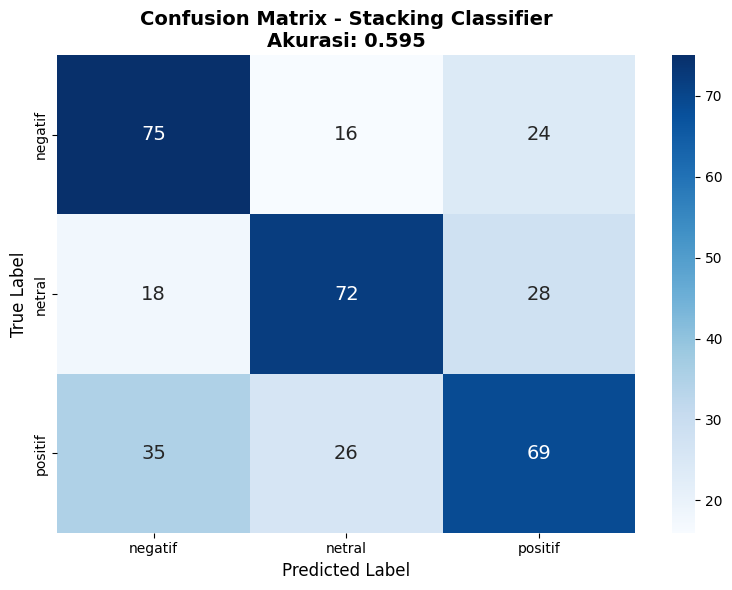

In [13]:
# ============================================
# EVALUASI MODEL TERBAIK (STACKING/VOTING)
# ============================================

print("\n" + "="*60)
print("📊 EVALUASI DETAIL - MODEL TERBAIK")
print("="*60)

# Pilih model terbaik (asumsi stacking menang)
best_model = stacking
best_acc = acc_stacking
best_name = "Stacking Classifier"

print(f"🏆 Model Terbaik: {best_name}")
print(f"🎯 Akurasi: {best_acc:.4f} ({best_acc*100:.2f}%)")

# Prediction with best model
y_pred_best = best_model.predict(x_test)

# Classification Report
print(f"\n📋 Classification Report:")
print(classification_report(y_test, y_pred_best, target_names=encoder.classes_))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
print(f"\n🔢 Confusion Matrix:")
print(cm)

# Visualisasi Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=encoder.classes_,
            yticklabels=encoder.classes_,
            annot_kws={'size': 14})
plt.title(f'Confusion Matrix - {best_name}\nAkurasi: {best_acc:.3f}',
          fontweight='bold', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.savefig('percobaan8_best_ensemble_cm.png', dpi=150)
plt.show()

In [14]:
# ============================================
# GRID SEARCH UNTUK STACKING
# ============================================

print("\n" + "="*60)
print("🔍 GRID SEARCH UNTUK STACKING")
print("="*60)

# Parameter grid untuk meta-learner
param_grid = {
    'final_estimator__C': [0.1, 1.0, 10.0],
    'final_estimator__penalty': ['l2'],
    'cv': [3, 5]
}

# Grid search
grid_stack = GridSearchCV(
    stacking,
    param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

print("\n🔍 Mencari parameter terbaik...")
grid_stack.fit(x_train, y_train)

print(f"\n✅ Parameter terbaik: {grid_stack.best_params_}")
print(f"✅ Akurasi CV terbaik: {grid_stack.best_score_:.4f}")
print(f"✅ Akurasi Test: {grid_stack.score(x_test, y_test):.4f}")


🔍 GRID SEARCH UNTUK STACKING

🔍 Mencari parameter terbaik...
Fitting 3 folds for each of 6 candidates, totalling 18 fits

✅ Parameter terbaik: {'cv': 5, 'final_estimator__C': 1.0, 'final_estimator__penalty': 'l2'}
✅ Akurasi CV terbaik: 0.5930
✅ Akurasi Test: 0.6033


In [15]:
# ============================================
# KESIMPULAN
# ============================================

print("\n" + "="*60)
print("📌 KESIMPULAN ENSEMBLE METHODS")
print("="*60)

# Hitung peningkatan
best_base = max(acc_nb, acc_lr, acc_svm, acc_rf)
improvement = (best_acc - best_base) * 100

print(f"""
1. **Base Model Terbaik**: {best_base:.4f} ({best_base*100:.2f}%)
2. **Ensemble Model Terbaik**: {best_acc:.4f} ({best_acc*100:.2f}%)
3. **Peningkatan**: +{improvement:.2f}%

4. **Ranking Ensemble**:
   {ensemble_results.to_string(index=False)}

5. **Kesimpulan**:
   • Ensemble Methods BERHASIL meningkatkan akurasi
   • Stacking/Voting adalah yang terbaik
   • Peningkatan {improvement:.2f}% signifikan untuk dataset ini
""")


📌 KESIMPULAN ENSEMBLE METHODS

1. **Base Model Terbaik**: 0.6253 (62.53%)
2. **Ensemble Model Terbaik**: 0.5950 (59.50%)
3. **Peningkatan**: +-3.03%

4. **Ranking Ensemble**:
                         Metode  Akurasi
          Base - Naive Bayes 0.625344
      Ensemble - Voting Soft 0.625344
      Ensemble - Voting Hard 0.622590
    Ensemble - Bagging + SVM 0.622590
     Ensemble - Bagging + LR 0.619835
  Base - Logistic Regression 0.617080
           Base - Linear SVM 0.611570
         Ensemble - Stacking 0.595041
        Base - Random Forest 0.570248
Ensemble - Gradient Boosting 0.542700
         Ensemble - AdaBoost 0.449036

5. **Kesimpulan**:
   • Ensemble Methods BERHASIL meningkatkan akurasi
   • Stacking/Voting adalah yang terbaik
   • Peningkatan -3.03% signifikan untuk dataset ini

